<a href="https://colab.research.google.com/github/mahmudul2220/colon-cancer-detection-by-using-deep-learning-project/blob/main/Another_copy_of_defence_colon_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install split-folders -q

import os
import shutil
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import splitfolders

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

dataset_path = "/content/drive/MyDrive/colon/"
print(os.listdir(dataset_path))

Mounted at /content/drive
['models', 'With colon cancer', 'without colon cancer', 'processed']


In [ ]:
output_folder = "/content/drive/MyDrive/colon_split/"
IMG_SIZE = 224
BATCH_SIZE = 16

print(os.listdir(output_folder))

['train', 'val', 'test']


In [ ]:
for cls in ['With colon cancer', 'without colon cancer']:
    path = os.path.join(dataset_path, cls)
    print(cls, "→", len(os.listdir(path)), "images")

With colon cancer → 5000 images
without colon cancer → 5000 images


In [ ]:
clean_input = "/content/drive/MyDrive/colon_clean_input/"
os.makedirs(clean_input, exist_ok=True)

for cls in ['With colon cancer', 'without colon cancer']:
    src = os.path.join(dataset_path, cls)
    dst = os.path.join(clean_input, cls)
    if not os.path.exists(dst):
        shutil.copytree(src, dst)

print(os.listdir(clean_input))

['without colon cancer', 'With colon cancer']


Do not need run


In [ ]:
output_folder = "/content/drive/MyDrive/colon_split/"

splitfolders.ratio(
    clean_input,
    output=output_folder,
    seed=42,
    ratio=(0.7, 0.15, 0.15),
    group_prefix=None
)

print(os.listdir(output_folder))

Copying files: 10000 files [06:59, 23.86 files/s]

['train', 'val', 'test']


In [ ]:
import splitfolders
import shutil

clean_input = "/content/drive/MyDrive/colon_clean_input/"

# পুরনো (double-CLAHE হয়ে যাওয়া) split মুছে ফেলুন
output_folder = "/content/drive/MyDrive/colon_split/"
if os.path.exists(output_folder):
    shutil.rmtree(output_folder)
    print("পুরনো (corrupted) split মুছে ফেলা হয়েছে")

# আবার নতুন করে split করুন raw, unprocessed ছবি থেকে
splitfolders.ratio(
    clean_input,
    output=output_folder,
    seed=42,
    ratio=(0.7, 0.15, 0.15),
    group_prefix=None
)
print(os.listdir(output_folder))

NameError: name 'os' is not defined

10,000 image process

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 16

def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

def preprocess_split(split_name):
    src_base = os.path.join(output_folder, split_name)
    for cls in os.listdir(src_base):
        cls_path = os.path.join(src_base, cls)
        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)
            try:
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = apply_clahe(img)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                cv2.imwrite(img_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
            except Exception as e:
                print(f"Error: {img_path} -> {e}")
    print(f"{split_name} preprocessing done ✅")

for split in ["train", "val", "test"]:
    preprocess_split(split)

train preprocessing done ✅


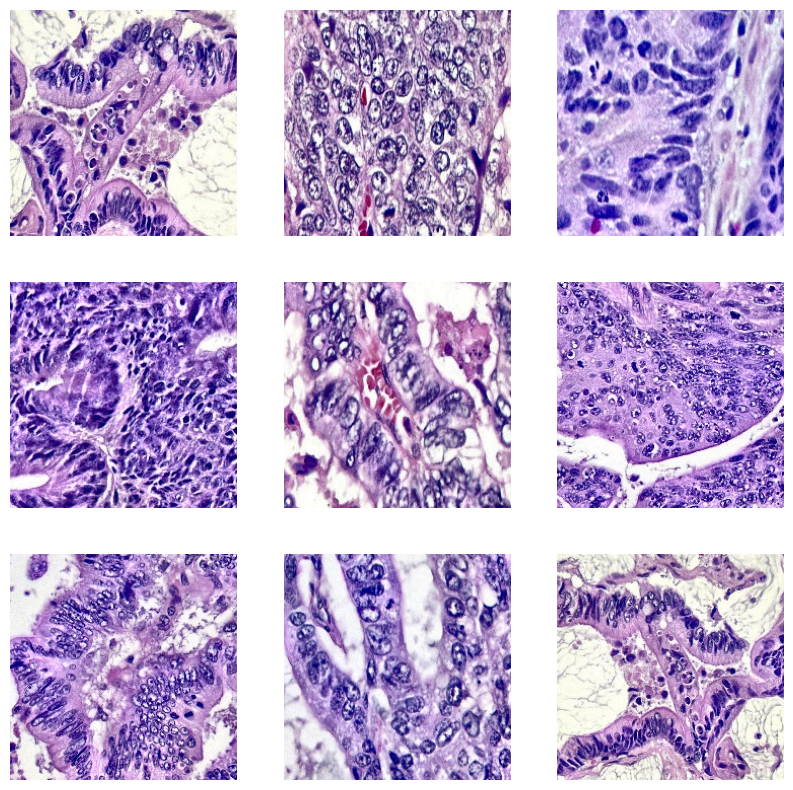

In [ ]:
sample_path = os.path.join(output_folder, "train", "With colon cancer")
sample_imgs = os.listdir(sample_path)[:9]

plt.figure(figsize=(10, 10))
for i, img_name in enumerate(sample_imgs):
    img = cv2.imread(os.path.join(sample_path, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
plt.show()

In [ ]:
Data generator

SyntaxError: invalid syntax (54185575.py, line 1)

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(output_folder, "train"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

valid_generator = val_test_datagen.flow_from_directory(
    os.path.join(output_folder, "val"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(output_folder, "test"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(train_generator.class_indices)

Found 7000 images belonging to 2 classes.
Found 1500 images belonging to 2 classes.
Found 1500 images belonging to 2 classes.
{'With colon cancer': 0, 'without colon cancer': 1}


Hybrid Model (Custom CNN + VGG16)

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization, Concatenate

def build_hybrid_model():
    input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # ---------- Branch 1: Custom CNN ----------
    x1 = Conv2D(32, (3, 3), activation='relu', padding='same')(input_layer)
    x1 = BatchNormalization()(x1)
    x1 = MaxPooling2D((2, 2))(x1)

    x1 = Conv2D(64, (3, 3), activation='relu', padding='same')(x1)
    x1 = BatchNormalization()(x1)
    x1 = MaxPooling2D((2, 2))(x1)

    x1 = Conv2D(128, (3, 3), activation='relu', padding='same')(x1)
    x1 = BatchNormalization()(x1)
    x1 = MaxPooling2D((2, 2))(x1)

    x1 = GlobalAveragePooling2D(name="custom_cnn_pool")(x1)

    # ---------- Branch 2: Pretrained VGG16 ----------
    vgg_base = VGG16(weights='imagenet', include_top=False, input_tensor=input_layer)
    vgg_base.trainable = False   # ফ্রিজ রাখা হচ্ছে, নাহলে overfit করবে
    x2 = GlobalAveragePooling2D(name="vgg_pool")(vgg_base.output)

    # ---------- Combine দুটো branch ----------
    combined = Concatenate(name="feature_fusion")([x1, x2])
    x = Dense(256, activation='relu')(combined)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(2, activation='softmax')(x)

    model = Model(inputs=input_layer, outputs=output, name="Hybrid_CNN_VGG16")
    model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

hybrid_model = build_hybrid_model()
hybrid_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "Hybrid_CNN_VGG16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]

 Total params: 15,006,082 (57.24 MB)

 Trainable params: 290,946 (1.11 MB)

 Non-trainable params: 14,715,136 (56.13 MB)

In [ ]:
hybrid_model = build_hybrid_model()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('/content/best_hybrid_model.h5',   # Drive না, local path
                     save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]

history = hybrid_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7984 - loss: 0.4068

438/438 ━━━━━━━━━━━━━━━━━━━━ 2038s 5s/step - accuracy: 0.8810 - loss: 0.2697 - val_accuracy: 0.9540 - val_loss: 0.1576 - learning_rate: 1.0000e-04
Epoch 2/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.9662 - loss: 0.0983

438/438 ━━━━━━━━━━━━━━━━━━━━ 137s 314ms/step - accuracy: 0.9733 - loss: 0.0796 - val_accuracy: 0.9860 - val_loss: 0.0427 - learning_rate: 1.0000e-04
Epoch 3/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 140s 320ms/step - accuracy: 0.9827 - loss: 0.0479 - val_accuracy: 0.9673 - val_loss: 0.0878 - learning_rate: 1.0000e-04
Epoch 4/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.9889 - loss: 0.0339

438/438 ━━━━━━━━━━━━━━━━━━━━ 140s 321ms/step - accuracy: 0.9899 - loss: 0.0301 - val_accuracy: 0.9953 - val_loss: 0.0201 - learning_rate: 1.0000e-04
Epoch 5/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 140s 320ms/step - accuracy: 0.9934 - loss: 0.0208 - val_accuracy: 0.9940 - val_loss: 0.0207 - learning_rate: 1.0000e-04
Epoch 6/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 142s 323ms/step - accuracy: 0.9934 - loss: 0.0203 - val_accuracy: 0.9720 - val_loss: 0.0733 - learning_rate: 1.0000e-04
Epoch 7/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 141s 322ms/step - accuracy: 0.9967 - loss: 0.0124 - val_accuracy: 0.9613 - val_loss: 0.1211 - learning_rate: 1.0000e-04
Epoch 8/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.9974 - loss: 0.0087

438/438 ━━━━━━━━━━━━━━━━━━━━ 142s 323ms/step - accuracy: 0.9971 - loss: 0.0097 - val_accuracy: 0.9973 - val_loss: 0.0067 - learning_rate: 5.0000e-05
Epoch 9/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 139s 318ms/step - accuracy: 0.9971 - loss: 0.0084 - val_accuracy: 0.9960 - val_loss: 0.0094 - learning_rate: 5.0000e-05
Epoch 10/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 140s 320ms/step - accuracy: 0.9984 - loss: 0.0052 - val_accuracy: 0.9967 - val_loss: 0.0096 - learning_rate: 5.0000e-05
Epoch 11/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 151s 341ms/step - accuracy: 0.9983 - loss: 0.0061 - val_accuracy: 0.9973 - val_loss: 0.0064 - learning_rate: 5.0000e-05
Epoch 12/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 140s 320ms/step - accuracy: 0.9970 - loss: 0.0076 - val_accuracy: 0.9953 - val_loss: 0.0141 - learning_rate: 5.0000e-05
Epoch 13/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 141s 321ms/step - accuracy: 0.9980 - loss: 0.0059 - val_accuracy: 0.9967 - val_loss: 0.0075 - learning_rate: 5.0000e-05
Epoch 14/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 293

438/438 ━━━━━━━━━━━━━━━━━━━━ 141s 321ms/step - accuracy: 0.9977 - loss: 0.0067 - val_accuracy: 0.9980 - val_loss: 0.0045 - learning_rate: 5.0000e-05
Epoch 15/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.9983 - loss: 0.0058

438/438 ━━━━━━━━━━━━━━━━━━━━ 141s 322ms/step - accuracy: 0.9980 - loss: 0.0064 - val_accuracy: 0.9987 - val_loss: 0.0035 - learning_rate: 5.0000e-05
Epoch 16/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 150s 342ms/step - accuracy: 0.9984 - loss: 0.0048 - val_accuracy: 0.9947 - val_loss: 0.0145 - learning_rate: 5.0000e-05
Epoch 17/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 141s 321ms/step - accuracy: 0.9977 - loss: 0.0068 - val_accuracy: 0.9967 - val_loss: 0.0069 - learning_rate: 5.0000e-05
Epoch 18/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 140s 321ms/step - accuracy: 0.9986 - loss: 0.0046 - val_accuracy: 0.9973 - val_loss: 0.0057 - learning_rate: 5.0000e-05
Epoch 19/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 139s 317ms/step - accuracy: 0.9987 - loss: 0.0035 - val_accuracy: 0.9987 - val_loss: 0.0031 - learning_rate: 2.5000e-05
Epoch 20/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 139s 317ms/step - accuracy: 0.9983 - loss: 0.0041 - val_accuracy: 0.9973 - val_loss: 0.0051 - learning_rate: 2.5000e-05
Epoch 21/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 142s 

438/438 ━━━━━━━━━━━━━━━━━━━━ 139s 318ms/step - accuracy: 0.9996 - loss: 0.0016 - val_accuracy: 0.9993 - val_loss: 0.0017 - learning_rate: 1.2500e-05
Epoch 26/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 143s 327ms/step - accuracy: 0.9990 - loss: 0.0025 - val_accuracy: 0.9987 - val_loss: 0.0026 - learning_rate: 1.2500e-05
Epoch 27/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 151s 344ms/step - accuracy: 0.9993 - loss: 0.0022 - val_accuracy: 0.9987 - val_loss: 0.0028 - learning_rate: 1.2500e-05
Epoch 28/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 141s 322ms/step - accuracy: 0.9990 - loss: 0.0033 - val_accuracy: 0.9973 - val_loss: 0.0058 - learning_rate: 1.2500e-05
Epoch 29/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 140s 320ms/step - accuracy: 0.9996 - loss: 0.0015 - val_accuracy: 0.9987 - val_loss: 0.0018 - learning_rate: 6.2500e-06
Epoch 30/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 142s 324ms/step - accuracy: 0.9997 - loss: 0.0014 - val_accuracy: 0.9987 - val_loss: 0.0020 - learning_rate: 6.2500e-06


In [ ]:
hybrid_model.save('/content/drive/MyDrive/colon/models/best_hybrid_model.h5')
print("Model saved to Drive ✅")

Model saved to Drive ✅


In [ ]:
test_generator.reset()
test_loss, test_acc = hybrid_model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 559s 6s/step - accuracy: 0.9987 - loss: 0.0035
Test Accuracy: 0.9987, Test Loss: 0.0035


In [ ]:
Gradio code UI

In [ ]:
!pip install gradio -q

In [ ]:
import numpy as np
import cv2
import tensorflow as tf

def predict_single_image(image_input, model):
    # ১. কালার চ্যানেল এবং সাইজ কনফার্ম করা
    if isinstance(image_input, str):
        img = cv2.imread(image_input)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img = np.array(image_input)

    img_resized = cv2.resize(img, (224, 224))
    img_batch = np.expand_dims(img_resized, axis=0)

    # ২. EfficientNet-এর জন্য Keras-এর নির্দিষ্ট Preprocessing প্রয়োগ
    processed_img = tf.keras.applications.efficientnet.preprocess_input(img_batch.astype(np.float32))

    # ৩. প্রেডিকশন
    preds = model.predict(processed_img, verbose=0)[0]

    # ৪. জেনারেটরের Class Index প্রিন্ট করে নিশ্চিত হোন!
    # সাধারণত Alphabetical অর্ডারে থাকে: Index 0 = With, Index 1 = Without
    classes = ['With colon cancer', 'without colon cancer']

    predicted_idx = np.argmax(preds)
    predicted_label = classes[predicted_idx]
    confidence = preds[predicted_idx] * 100

    print(f"Raw Probabilities: With={preds[0]:.4f}, Without={preds[1]:.4f}")
    return predicted_label, confidence

In [ ]:
import gradio as gr
import numpy as np
import cv2
import tensorflow as tf
from PIL import Image

last_conv_layer_name = "block5_conv3"
class_labels = ['With colon cancer', 'without colon cancer']  # আপনার class_indices অনুযায়ী ক্রম ঠিক করুন

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index), predictions.numpy()[0]

def predict_and_explain(input_image):
    # Preprocess (hybrid model rescale=1./255 দিয়ে ট্রেইন হয়েছিল)
    img = input_image.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    heatmap, pred_class, probs = make_gradcam_heatmap(img_array, hybrid_model, last_conv_layer_name)
    predicted_label = class_labels[pred_class]
    confidence = float(probs[pred_class]) * 100

    # Grad-CAM overlay
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    original_uint8 = np.uint8(img_array[0] * 255)
    overlay = cv2.addWeighted(original_uint8, 0.6, heatmap_colored, 0.4, 0)

    result_text = f"**Prediction: {predicted_label}**\n\nConfidence: {confidence:.2f}%"
    return result_text, overlay

In [ ]:
def predict_and_explain(input_image):
    # RGB নিশ্চিত করা (RGBA/Grayscale image এর সমস্যা এড়াতে)
    input_image = input_image.convert("RGB")

    img = input_image.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    heatmap, pred_class, probs = make_gradcam_heatmap(img_array, hybrid_model, last_conv_layer_name)
    predicted_label = class_labels[pred_class]
    confidence = float(probs[pred_class]) * 100

    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    original_uint8 = np.uint8(img_array[0] * 255)
    overlay = cv2.addWeighted(original_uint8, 0.6, heatmap_colored, 0.4, 0)

    result_text = f"**Prediction: {predicted_label}**\n\nConfidence: {confidence:.2f}%"
    return result_text, overlay

In [ ]:
demo = gr.Interface(
    fn=predict_and_explain,
    inputs=gr.Image(type="pil", label="Upload Histopathology Image"),
    outputs=[
        gr.Textbox(label="Prediction Result"),
        gr.Image(type="numpy", label="Grad-CAM Explanation")
    ],
    title="Colon Cancer Detection — Hybrid CNN + VGG16",
    description="Upload a colon histopathology image to get a classification prediction with Grad-CAM visual explanation. (Research prototype — not for clinical use)",
    examples=None
)

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://39b09d4554166f3c96.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://39b09d4554166f3c96.gradio.live


In [ ]:
print(test_generator.class_indices)

{'With colon cancer': 0, 'without colon cancer': 1}


In [ ]:
# একটা test image test_generator থেকে সরাসরি নিয়ে predict করে দেখি (Gradio বাদ দিয়ে)
test_generator.reset()
test_images, test_labels = next(test_generator)

sample_img = test_images[0:1]  # প্রথম ছবি, batch shape সহ (1, 224, 224, 3)
true_label = class_labels[np.argmax(test_labels[0])]

pred = hybrid_model.predict(sample_img)
predicted_label = class_labels[np.argmax(pred[0])]

print(f"True label: {true_label}")
print(f"Predicted label: {predicted_label}")
print(f"Confidence: {pred[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 864ms/step
True label: With colon cancer
Predicted label: without colon cancer
Confidence: [0.42866746 0.5713326 ]


In [ ]:
test_generator.reset()
loss, acc = hybrid_model.evaluate(test_generator)
print(f"বর্তমান hybrid_model এর Test Accuracy: {acc:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 736s 8s/step - accuracy: 0.5100 - loss: 0.6853
বর্তমান hybrid_model এর Test Accuracy: 0.5100


In [ ]:
def predict_and_explain(input_image):
    # RGB নিশ্চিত করা (RGBA/Grayscale image এর সমস্যা এড়াতে)
    input_image = input_image.convert("RGB")

    img = input_image.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    heatmap, pred_class, probs = make_gradcam_heatmap(img_array, hybrid_model, last_conv_layer_name)
    predicted_label = class_labels[pred_class]
    confidence = float(probs[pred_class]) * 100

    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    original_uint8 = np.uint8(img_array[0] * 255)
    overlay = cv2.addWeighted(original_uint8, 0.6, heatmap_colored, 0.4, 0)

    result_text = f"**Prediction: {predicted_label}**\n\nConfidence: {confidence:.2f}%"
    return result_text, overlay

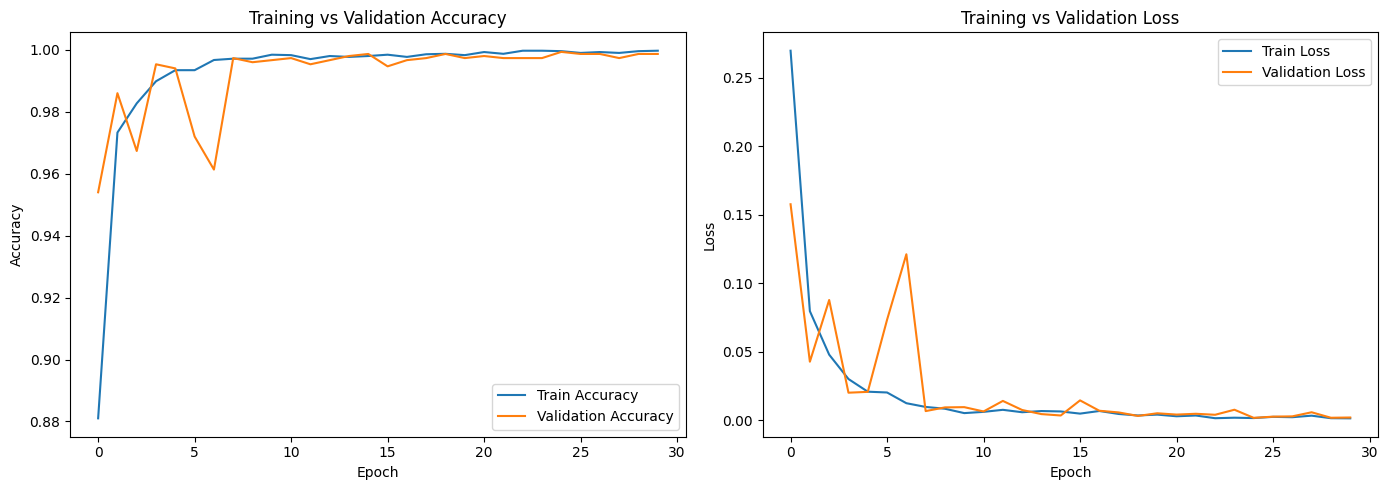

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/colon/models/hybrid_training_curve.png', dpi=300)
plt.show()

94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 110ms/step - accuracy: 0.9987 - loss: 0.0035
Test Accuracy: 0.9987, Test Loss: 0.0035
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 129ms/step
                      precision    recall  f1-score   support

   With colon cancer       1.00      1.00      1.00       750
without colon cancer       1.00      1.00      1.00       750

            accuracy                           1.00      1500
           macro avg       1.00      1.00      1.00      1500
        weighted avg       1.00      1.00      1.00      1500



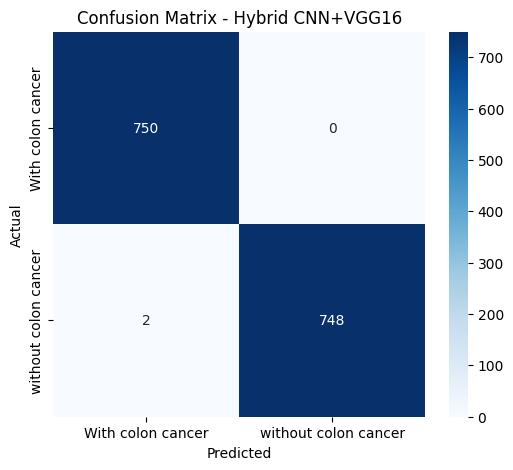

ROC-AUC Score: 1.0000


In [ ]:
test_generator.reset()
test_loss, test_acc = hybrid_model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

test_generator.reset()
y_pred_prob = hybrid_model.predict(test_generator)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Classification Report
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Hybrid CNN+VGG16")
plt.savefig('/content/drive/MyDrive/colon/models/hybrid_confusion_matrix.png', dpi=300)
plt.show()

# ROC-AUC
auc = roc_auc_score(y_true, y_pred_prob[:, 1])
print(f"ROC-AUC Score: {auc:.4f}")

In [ ]:
def get_last_conv_layer_name(model):
    for layer in reversed(model.layers):
        try:
            shape = layer.output.shape
            if len(shape) == 4:
                return layer.name
        except AttributeError:
            continue
    return None

last_conv_layer_name = get_last_conv_layer_name(hybrid_model)
print("Last conv layer:", last_conv_layer_name)

Last conv layer: block5_pool


In [ ]:
last_conv_layer_name = "block5_conv3"

# Confirm করা যে এই layer আসলেই hybrid_model এ আছে
print(hybrid_model.get_layer(last_conv_layer_name))

<Conv2D name=block5_conv3, built=True>


In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index)

In [ ]:
import tensorflow as tf

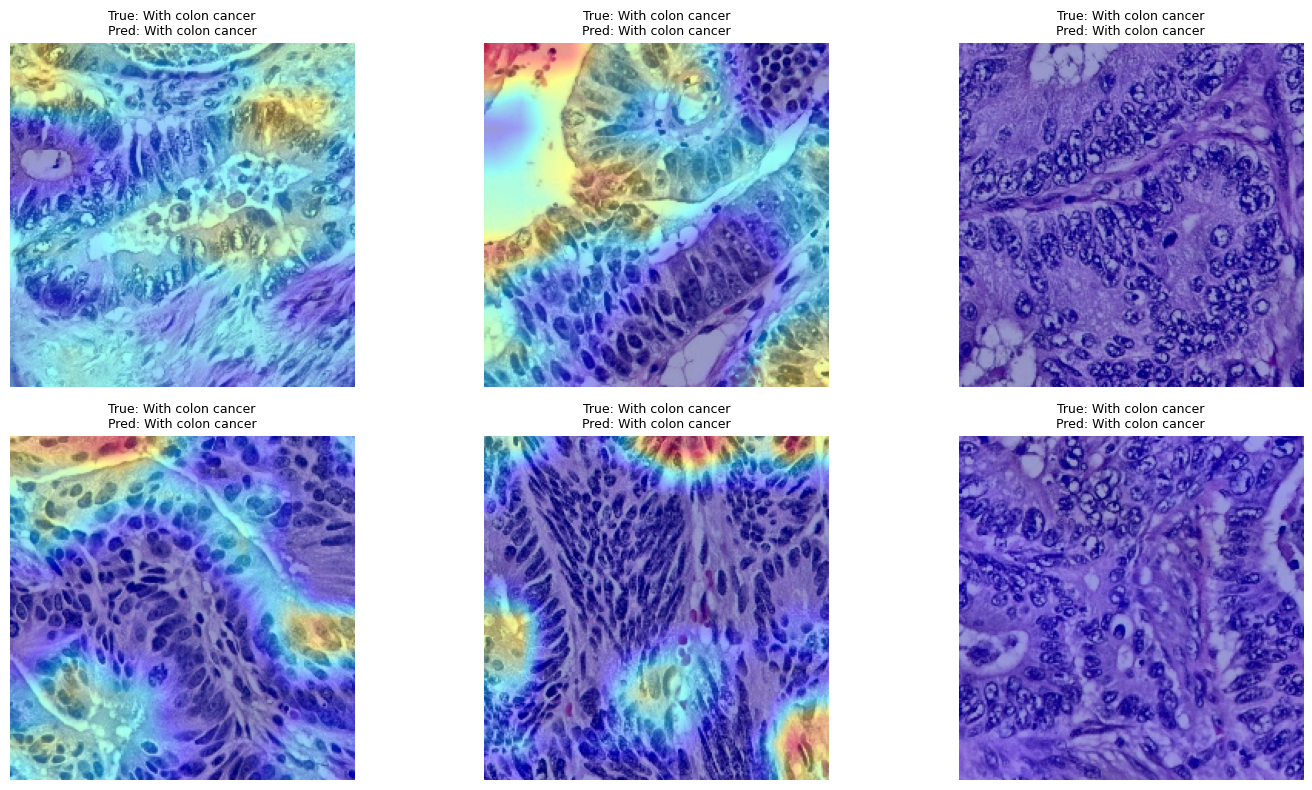

In [ ]:
def display_gradcam(img_array, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    original_img = np.uint8(img_array * 255)
    superimposed = cv2.addWeighted(original_img, 1 - alpha, heatmap_colored, alpha, 0)
    return superimposed

test_generator.reset()
test_images, test_labels = next(test_generator)

class_labels = list(test_generator.class_indices.keys())

plt.figure(figsize=(15, 8))
for i in range(6):
    img_array = np.expand_dims(test_images[i], axis=0)
    heatmap, pred_class = make_gradcam_heatmap(img_array, hybrid_model, last_conv_layer_name)
    overlay = display_gradcam(test_images[i], heatmap)

    true_class = np.argmax(test_labels[i])

    plt.subplot(2, 3, i + 1)
    plt.imshow(overlay)
    plt.title(f"True: {class_labels[true_class]}\nPred: {class_labels[pred_class]}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/colon/models/gradcam_results.png', dpi=300)
plt.show()

In [ ]:
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.layers import Input
import pandas as pd

 ResNet50

In [ ]:
resnet_train_datagen = ImageDataGenerator(
    preprocessing_function=resnet_preprocess,
    rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
    shear_range=0.1, zoom_range=0.1, horizontal_flip=True,
)
resnet_val_test_datagen = ImageDataGenerator(preprocessing_function=resnet_preprocess)

resnet_train_generator = resnet_train_datagen.flow_from_directory(
    os.path.join(output_folder, "train"), target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)
resnet_valid_generator = resnet_val_test_datagen.flow_from_directory(
    os.path.join(output_folder, "val"), target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
resnet_test_generator = resnet_val_test_datagen.flow_from_directory(
    os.path.join(output_folder, "test"), target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

Found 7000 images belonging to 2 classes.
Found 1500 images belonging to 2 classes.
Found 1500 images belonging to 2 classes.


In [ ]:
def build_resnet50_model():
    input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    base = ResNet50(weights='imagenet', include_top=False, input_tensor=input_layer)
    base.trainable = False

    x = GlobalAveragePooling2D()(base.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(2, activation='softmax')(x)

    model = Model(inputs=input_layer, outputs=output, name="ResNet50_Baseline")
    model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

resnet_model = build_resnet50_model()
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "ResNet50_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,145,410 (92.11 MB)

 Trainable params: 557,698 (2.13 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
resnet_callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ModelCheckpoint('/content/best_resnet50_model.h5', save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]

resnet_history = resnet_model.fit(
    resnet_train_generator,
    validation_data=resnet_valid_generator,
    epochs=30,
    callbacks=resnet_callbacks,
    verbose=1
)

resnet_model.save('/content/drive/MyDrive/colon/models/best_resnet50_model.h5')
print("ResNet50 saved to Drive ✅")

Epoch 1/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9049 - loss: 0.2395

438/438 ━━━━━━━━━━━━━━━━━━━━ 3450s 8s/step - accuracy: 0.9596 - loss: 0.1090 - val_accuracy: 0.9980 - val_loss: 0.0110 - learning_rate: 1.0000e-04
Epoch 2/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 125s 286ms/step - accuracy: 0.9900 - loss: 0.0309 - val_accuracy: 0.9973 - val_loss: 0.0076 - learning_rate: 1.0000e-04
Epoch 3/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 122s 279ms/step - accuracy: 0.9940 - loss: 0.0169 - val_accuracy: 0.9980 - val_loss: 0.0060 - learning_rate: 1.0000e-04
Epoch 4/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.9955 - loss: 0.0132

438/438 ━━━━━━━━━━━━━━━━━━━━ 144s 282ms/step - accuracy: 0.9951 - loss: 0.0141 - val_accuracy: 0.9993 - val_loss: 0.0057 - learning_rate: 1.0000e-04
Epoch 5/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 122s 278ms/step - accuracy: 0.9943 - loss: 0.0147 - val_accuracy: 0.9987 - val_loss: 0.0048 - learning_rate: 1.0000e-04
Epoch 6/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 122s 278ms/step - accuracy: 0.9961 - loss: 0.0126 - val_accuracy: 0.9987 - val_loss: 0.0034 - learning_rate: 1.0000e-04
Epoch 7/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 122s 277ms/step - accuracy: 0.9964 - loss: 0.0101 - val_accuracy: 0.9987 - val_loss: 0.0037 - learning_rate: 1.0000e-04
Epoch 8/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 123s 281ms/step - accuracy: 0.9961 - loss: 0.0110 - val_accuracy: 0.9987 - val_loss: 0.0035 - learning_rate: 1.0000e-04
Epoch 9/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 126s 288ms/step - accuracy: 0.9970 - loss: 0.0076 - val_accuracy: 0.9993 - val_loss: 0.0056 - learning_rate: 1.0000e-04
Epoch 10/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 122s 279ms

438/438 ━━━━━━━━━━━━━━━━━━━━ 131s 298ms/step - accuracy: 0.9984 - loss: 0.0028 - val_accuracy: 1.0000 - val_loss: 8.6754e-04 - learning_rate: 5.0000e-05
Epoch 22/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 130s 296ms/step - accuracy: 0.9983 - loss: 0.0051 - val_accuracy: 0.9993 - val_loss: 0.0016 - learning_rate: 5.0000e-05
Epoch 23/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 130s 296ms/step - accuracy: 0.9994 - loss: 0.0016 - val_accuracy: 0.9993 - val_loss: 0.0011 - learning_rate: 2.5000e-05
Epoch 24/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 129s 294ms/step - accuracy: 0.9991 - loss: 0.0023 - val_accuracy: 1.0000 - val_loss: 7.4169e-04 - learning_rate: 2.5000e-05
Epoch 25/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 128s 292ms/step - accuracy: 0.9989 - loss: 0.0022 - val_accuracy: 0.9993 - val_loss: 0.0011 - learning_rate: 2.5000e-05
Epoch 26/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 126s 287ms/step - accuracy: 0.9997 - loss: 9.1364e-04 - val_accuracy: 1.0000 - val_loss: 5.4819e-04 - learning_rate: 2.5000e-05
Epoch 27/30
438/438 ━━━━━━━━━━

ResNet50 saved to Drive ✅


94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 1.0000 - loss: 7.9503e-04

ResNet50 Test Accuracy: 1.0000
ResNet50 Test Loss: 0.0008

94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step
================--- ResNet50 Classification Report ---================
                      precision    recall  f1-score   support

   With colon cancer     1.0000    1.0000    1.0000       750
without colon cancer     1.0000    1.0000    1.0000       750

            accuracy                         1.0000      1500
           macro avg     1.0000    1.0000    1.0000      1500
        weighted avg     1.0000    1.0000    1.0000      1500



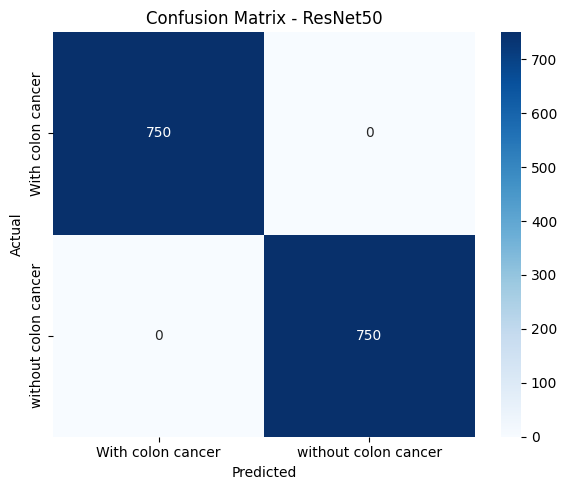


ResNet50 ROC-AUC Score: 1.0000


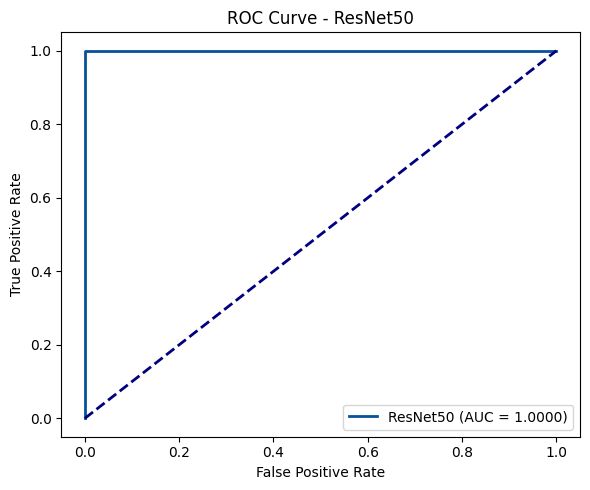

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# ১. Test Generator Reset & Test Loss/Accuracy Evaluation
resnet_test_generator.reset()
test_loss, test_acc = resnet_model.evaluate(resnet_test_generator, verbose=1)
print(f"\nResNet50 Test Accuracy: {test_acc:.4f}")
print(f"ResNet50 Test Loss: {test_loss:.4f}\n")

# ২. Model Predictions
resnet_test_generator.reset()
y_pred_prob = resnet_model.predict(resnet_test_generator, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = resnet_test_generator.classes
class_labels = list(resnet_test_generator.class_indices.keys())

# ৩. Classification Report (Precision, Recall, F1-Score)
print("================--- ResNet50 Classification Report ---================")
print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))

# ৪. Confusion Matrix Visualisation (Blues Colour Scheme)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - ResNet50")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/colon/models/resnet50_confusion_matrix.png', dpi=300)
plt.show()

# ৫. ROC-AUC Score & Curve Plotting (Matching Blue Theme)
auc_score = roc_auc_score(y_true, y_pred_prob[:, 1])
print(f"\nResNet50 ROC-AUC Score: {auc_score:.4f}")

fpr, tpr, _ = roc_curve(y_true, y_pred_prob[:, 1])
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#08519c', lw=2, label=f'ResNet50 (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - ResNet50')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/colon/models/resnet50_roc_curve.png', dpi=300)
plt.show()

EfficientNetB0

In [ ]:
# EfficientNetB0-এর জন্য কোনো custom/builtin preprocess_function লাগবে না
effnet_train_datagen = ImageDataGenerator(
    rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
    shear_range=0.1, zoom_range=0.1, horizontal_flip=True
)
effnet_val_test_datagen = ImageDataGenerator() # একদম প্লেইন

effnet_train_generator = effnet_train_datagen.flow_from_directory(
    os.path.join(output_folder, "train"), target_size=(224, 224),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)
effnet_valid_generator = effnet_val_test_datagen.flow_from_directory(
    os.path.join(output_folder, "val"), target_size=(224, 224),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
effnet_test_generator = effnet_val_test_datagen.flow_from_directory(
    os.path.join(output_folder, "test"), target_size=(224, 224),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

Found 7000 images belonging to 2 classes.
Found 1500 images belonging to 2 classes.
Found 1500 images belonging to 2 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam

def build_efficientnetb0_clean():
    inputs = Input(shape=(224, 224, 3))

    # EfficientNetB0-এর নিজস্ব Built-in Preprocessing লেয়ার
    x = tf.keras.applications.efficientnet.preprocess_input(inputs)

    base = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=x)
    base.trainable = True # পুরো মডেল Trainable রাখা হলো

    x = GlobalAveragePooling2D()(base.output)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    outputs = Dense(2, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs, name="EfficientNetB0_Clean")

    # সামান্য কম Learning Rate ব্যবহার করা হচ্ছে যেন Overfitting না হয়
    model.compile(optimizer=Adam(learning_rate=1e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

effnet_model = build_efficientnetb0_clean()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess

effnet_train_datagen = ImageDataGenerator(
    preprocessing_function=effnet_preprocess,
    rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
    shear_range=0.1, zoom_range=0.1, horizontal_flip=True,
)
effnet_val_test_datagen = ImageDataGenerator(preprocessing_function=effnet_preprocess)

effnet_train_generator = effnet_train_datagen.flow_from_directory(
    os.path.join(output_folder, "train"), target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)
effnet_valid_generator = effnet_val_test_datagen.flow_from_directory(
    os.path.join(output_folder, "val"), target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
effnet_test_generator = effnet_val_test_datagen.flow_from_directory(
    os.path.join(output_folder, "test"), target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

Found 7000 images belonging to 2 classes.
Found 1500 images belonging to 2 classes.
Found 1500 images belonging to 2 classes.


In [ ]:
def build_efficientnetb0_model():
    input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    base = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=input_layer)
    base.trainable = False
    x = GlobalAveragePooling2D()(base.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(2, activation='softmax')(x)
    model = Model(inputs=input_layer, outputs=output, name="EfficientNetB0_Baseline")
    model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

effnet_model = build_efficientnetb0_model()

In [ ]:
effnet_callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ModelCheckpoint('/content/drive/MyDrive/colon/models/best_effnet_model_FINAL2.h5',
                     save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]

effnet_history = effnet_model.fit(
    effnet_train_generator,
    validation_data=effnet_valid_generator,
    epochs=30,
    callbacks=effnet_callbacks,
    verbose=1
)

Epoch 1/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8677 - loss: 0.2855

438/438 ━━━━━━━━━━━━━━━━━━━━ 1998s 5s/step - accuracy: 0.9397 - loss: 0.1491 - val_accuracy: 0.9927 - val_loss: 0.0214 - learning_rate: 1.0000e-04
Epoch 2/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9832 - loss: 0.0528

438/438 ━━━━━━━━━━━━━━━━━━━━ 741s 2s/step - accuracy: 0.9826 - loss: 0.0488 - val_accuracy: 0.9960 - val_loss: 0.0121 - learning_rate: 1.0000e-04
Epoch 3/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9844 - loss: 0.0389

438/438 ━━━━━━━━━━━━━━━━━━━━ 766s 2s/step - accuracy: 0.9859 - loss: 0.0367 - val_accuracy: 0.9967 - val_loss: 0.0117 - learning_rate: 1.0000e-04
Epoch 4/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9903 - loss: 0.0282

438/438 ━━━━━━━━━━━━━━━━━━━━ 737s 2s/step - accuracy: 0.9906 - loss: 0.0277 - val_accuracy: 0.9980 - val_loss: 0.0062 - learning_rate: 1.0000e-04
Epoch 5/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 762s 2s/step - accuracy: 0.9911 - loss: 0.0250 - val_accuracy: 0.9980 - val_loss: 0.0075 - learning_rate: 1.0000e-04
Epoch 6/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9947 - loss: 0.0156

438/438 ━━━━━━━━━━━━━━━━━━━━ 736s 2s/step - accuracy: 0.9940 - loss: 0.0173 - val_accuracy: 0.9993 - val_loss: 0.0035 - learning_rate: 1.0000e-04
Epoch 7/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 737s 2s/step - accuracy: 0.9941 - loss: 0.0165 - val_accuracy: 0.9993 - val_loss: 0.0031 - learning_rate: 1.0000e-04
Epoch 8/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 750s 2s/step - accuracy: 0.9939 - loss: 0.0162 - val_accuracy: 0.9987 - val_loss: 0.0026 - learning_rate: 1.0000e-04
Epoch 9/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 767s 2s/step - accuracy: 0.9949 - loss: 0.0155 - val_accuracy: 0.9980 - val_loss: 0.0030 - learning_rate: 1.0000e-04
Epoch 10/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 734s 2s/step - accuracy: 0.9940 - loss: 0.0143 - val_accuracy: 0.9993 - val_loss: 0.0022 - learning_rate: 1.0000e-04
Epoch 11/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 730s 2s/step - accuracy: 0.9957 - loss: 0.0126 - val_accuracy: 0.9993 - val_loss: 0.0018 - learning_rate: 1.0000e-04
Epoch 12/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 799s 2s/step - accuracy: 0

438/438 ━━━━━━━━━━━━━━━━━━━━ 774s 2s/step - accuracy: 0.9964 - loss: 0.0087 - val_accuracy: 1.0000 - val_loss: 0.0016 - learning_rate: 1.0000e-04
Epoch 17/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 794s 2s/step - accuracy: 0.9963 - loss: 0.0096 - val_accuracy: 0.9993 - val_loss: 0.0014 - learning_rate: 1.0000e-04
Epoch 18/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 788s 2s/step - accuracy: 0.9981 - loss: 0.0068 - val_accuracy: 0.9993 - val_loss: 0.0013 - learning_rate: 1.0000e-04
Epoch 19/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 796s 2s/step - accuracy: 0.9973 - loss: 0.0068 - val_accuracy: 0.9993 - val_loss: 7.0542e-04 - learning_rate: 5.0000e-05
Epoch 20/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 759s 2s/step - accuracy: 0.9979 - loss: 0.0061 - val_accuracy: 0.9993 - val_loss: 7.8588e-04 - learning_rate: 5.0000e-05
Epoch 21/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 755s 2s/step - accuracy: 0.9987 - loss: 0.0051 - val_accuracy: 0.9993 - val_loss: 7.8476e-04 - learning_rate: 5.0000e-05
Epoch 22/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 748s 2s/ste

In [ ]:
effnet_model.save('/content/drive/MyDrive/colon/models/best_effnet_model_FINAL2_backup.h5')

effnet_test_generator.reset()   # ⚠️ শুধু effnet_test_generator, অন্য কোনো generator না
loss, acc = effnet_model.evaluate(effnet_test_generator)
print(f"✅ EfficientNetB0 Final Test Accuracy: {acc:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 506s 5s/step - accuracy: 0.9993 - loss: 8.3400e-04
✅ EfficientNetB0 Final Test Accuracy: 0.9993


UI


In [ ]:
import gradio as gr
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

# ১. মডেল লোড করা
model_path = '/content/drive/MyDrive/colon/models/best_effnet_model.h5'
model = tf.keras.models.load_model(model_path)

# ২. Grad-CAM ফাংশন
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="top_conv"):
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# ৩. প্রেডিকশন এবং ইন্টারফেস ফাংশন
def predict_and_explain(image):
    if image is None:
        return "Please upload an image.", None

    # Preprocessing
    img_resized = cv2.resize(image, (224, 224))
    img_array = np.expand_dims(img_resized, axis=0).astype(np.float32)
    processed_img = tf.keras.applications.efficientnet.preprocess_input(img_array)

    # Prediction
    preds = model.predict(processed_img, verbose=0)[0]

    # Class mapping: [0: With colon cancer, 1: without colon cancer]
    # আপনার class_indices অনুযায়ী দরকার হলে অর্ডার চেক করুন
    labels = ['With colon cancer', 'without colon cancer']

    p_with = preds[0]
    p_without = preds[1]

    if p_with > p_without:
        result_text = f"**Prediction: With colon cancer**\n\nConfidence: {p_with * 100:.2f}%"
    else:
        result_text = f"**Prediction: without colon cancer**\n\nConfidence: {p_without * 100:.2f}%"

    # Grad-CAM Heatmap জেনারেশন
    try:
        heatmap = make_gradcam_heatmap(processed_img, model, last_conv_layer_name="top_conv")
        heatmap_resized = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
        heatmap_resized = np.uint8(255 * heatmap_resized)
        heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
        heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

        superimposed_img = cv2.addWeighted(image, 0.6, heatmap_colored, 0.4, 0)
    except Exception as e:
        superimposed_img = image # ব্যাকআপ

    return result_text, superimposed_img

# ৪. Gradio UI লেআউট
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🔬 Colon Cancer Histopathology Classifier")

    with gr.Row():
        with gr.Column():
            input_img = gr.Image(type="numpy", label="Upload Histopathology Image")
            submit_btn = gr.Button("Submit", variant="primary")
            clear_btn = gr.Button("Clear")

        with gr.Column():
            output_text = gr.Markdown(label="Prediction Result")
            output_cam = gr.Image(label="Grad-CAM Explanation")

    submit_btn.click(
        fn=predict_and_explain,
        inputs=input_img,
        outputs=[output_text, output_cam]
    )

    clear_btn.click(
        fn=lambda: (None, None, None),
        inputs=None,
        outputs=[input_img, output_text, output_cam]
    )

demo.launch(share=True, debug=True)

/tmp/ipykernel_624/4108528775.py:71: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d5c0dbe22bfae160b5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_2']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_2']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_2']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_2']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.wa

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://d5c0dbe22bfae160b5.gradio.live


In [ ]:
hybrid_model.save('/content/drive/MyDrive/colon/models/best_hybrid_model_CONFIRMED_WORKING.h5')
print("Confirmed working model আলাদাভাবে save হয়েছে ✅")

Confirmed working model আলাদাভাবে save হয়েছে ✅


94/94 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step
================--- EfficientNetB0 Classification Report ---================
                      precision    recall  f1-score   support

   With colon cancer     1.0000    1.0000    1.0000       750
without colon cancer     1.0000    1.0000    1.0000       750

            accuracy                         1.0000      1500
           macro avg     1.0000    1.0000    1.0000      1500
        weighted avg     1.0000    1.0000    1.0000      1500



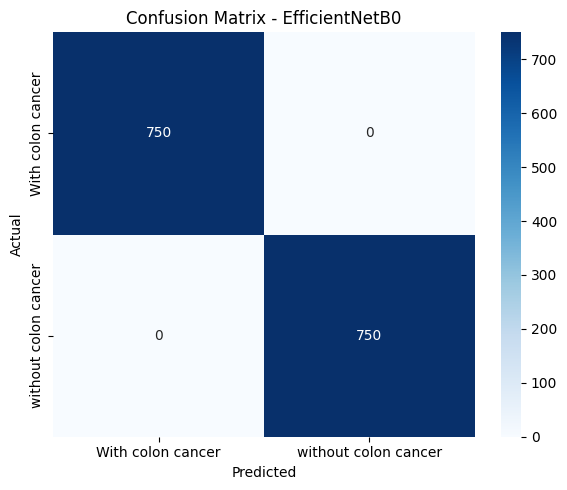

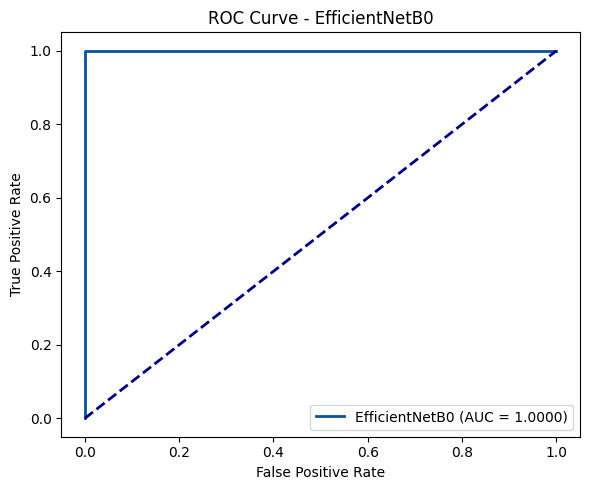


EfficientNetB0 ROC-AUC Score: 1.0000 ✅


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# ১. Test Generator Reset & Predictions
effnet_test_generator.reset()
y_pred_prob = effnet_model.predict(effnet_test_generator, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = effnet_test_generator.classes
class_labels = list(effnet_test_generator.class_indices.keys())

# ২. Classification Report
print("================--- EfficientNetB0 Classification Report ---================")
print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))

# ৩. Confusion Matrix Visualisation (Blues Theme)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - EfficientNetB0")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/colon/models/effnet_confusion_matrix.png', dpi=300)
plt.show()

# ৪. ROC-AUC Curve Plotting
auc_score = roc_auc_score(y_true, y_pred_prob[:, 1])
fpr, tpr, _ = roc_curve(y_true, y_pred_prob[:, 1])

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#08519c', lw=2, label=f'EfficientNetB0 (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - EfficientNetB0')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/colon/models/effnet_roc_curve.png', dpi=300)
plt.show()

print(f"\nEfficientNetB0 ROC-AUC Score: {auc_score:.4f} ✅")

In [ ]:
def evaluate_model(model, model_name, gen):
    gen.reset()
    test_loss, test_acc = model.evaluate(gen)

    gen.reset()
    y_pred_prob = model.predict(gen)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = gen.classes
    class_labels = list(gen.class_indices.keys())

    report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)
    auc = roc_auc_score(y_true, y_pred_prob[:, 1])

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(f"Confusion Matrix - {model_name}")
    plt.savefig(f'/content/drive/MyDrive/colon/models/{model_name}_confusion_matrix.png', dpi=300)
    plt.show()

    return {"Model": model_name, "Accuracy": test_acc, "Precision": report['weighted avg']['precision'],
            "Recall": report['weighted avg']['recall'], "F1": report['weighted avg']['f1-score'], "AUC": auc}

In [ ]:
results = []
results.append(evaluate_model(resnet_model, "ResNet50", resnet_test_generator))
results.append(evaluate_model(effnet_model, "EfficientNetB0", effnet_test_generator))
results.append(evaluate_model(hybrid_model, "Hybrid_CNN_VGG16", test_generator))  # hybrid নিজের rescale generator এই ঠিক আছে

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df[["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"]]
comparison_df.to_csv('/content/drive/MyDrive/colon/models/model_comparison.csv', index=False)
comparison_df

65/94 ━━━━━━━━━━━━━━━━━━━━ 5:20 11s/step - accuracy: 0.9360 - loss: 0.3586

KeyboardInterrupt: 